In [11]:
import numpy as np
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display

In [2]:
def KL(p, q):
  S = 0
  for i in range(len(p)):
    if p[i] != 0:
      S += p[i]*np.log(p[i]/q[i])
  return S

In [3]:
import numpy as np

def obtain_q0(G, max_iters=500000, T0=1.0, alpha=0.99999, s0=0.99):
    """
    Simulated annealing to minimize:
        C(q) = <fx>_q - S(q) + S(Gq)
    where q is a probability distribution vector.

    Parameters:
        G : np.ndarray
            Matrix of shape (N, M)
        max_iters : int
            Maximum number of iterations
        T0 : float
            Initial temperature
        alpha : float
            Cooling rate
        s0 : float
            Initial mixing parameter

    Returns:
        r0 : float
            Best objective value found
        qx : np.ndarray
            Corresponding probability vector
    """

    M = G.shape[1]
    q = np.random.rand(M)
    q = q / np.sum(q)
    qx = q.copy()

    fx = np.ones(M)

    def entropy(p):
        p = np.clip(p, 1e-12, 1.0)  # Avoid log(0)
        return -np.sum(p * np.log(p))

    def objective(q):
        Gq = G.T @ q
        return entropy(Gq)- entropy(q) + np.dot(fx, q)

    r0 = objective(q)
    T = T0
    s = s0

    for _ in range(max_iters):
        r = np.random.rand(M)
        r = r / np.sum(r)
        q_new = (1 - s) * r + s * q
        q_new = q_new / np.sum(q_new)

        r_new = objective(q_new)

        if (r_new < r0) or (np.random.rand() < np.exp(-(r_new - r0) / T)):
            q = q_new
            qx = q.copy()
            r0 = r_new

        T *= alpha
        s = max(0.9 * s, 0.1)

    return r0, qx


In [4]:

# ----------------------------
# Step 1: Define RASP Simulation
# ----------------------------

def heaviside_rasp(x, c, r, a):
    """Simulates the RASP-style execution of the heaviside function.
    Returns a list of state vectors at each step."""
    trace = []

    # Initialize registers: R1, R2, R3, R4, PC (Program Counter)
    R = {'R1': x, 'R2': c, 'R3': r, 'R4': a, 'PC': 0}

    # Step 1: READ R1, 103 and READ R2, 104 => already loaded in R1 and R2.
    trace.append([R['R1'], R['R2'], R['R3'], R['R4'], R['PC']])
    R['PC'] += 1

    # Step 3: SUB R1, R2, R3 => R3 = R1 - R2
    R['R3'] = R['R1'] - R['R2']
    trace.append([R['R1'], R['R2'], R['R3'], R['R4'], R['PC']])
    R['PC'] += 1

    # Step 4: JLE R3, ELSE => if R3 <= 0, jump to ELSE
    if R['R3'] <= 0:
        R['PC'] = 4  # ELSE block
    else:
        R['PC'] += 1
    trace.append([R['R1'], R['R2'], R['R3'], R['R4'], R['PC']])

    # Step 5: LOAD R4, 1 (a = 1)
    if R['PC'] == 3:
        R['R4'] = 1
        R['PC'] += 2  # Skip ELSE
        trace.append([R['R1'], R['R2'], R['R3'], R['R4'], R['PC']])

    # ELSE block: LOAD R4, 0
    if R['PC'] == 4:
        R['R4'] = 0
        R['PC'] += 1
        trace.append([R['R1'], R['R2'], R['R3'], R['R4'], R['PC']])

    # END: RETURN R4
    trace.append([R['R1'], R['R2'], R['R3'], R['R4'], R['PC']])
    return trace

# ----------------------------
# Step 2: Build the Graph
# ----------------------------

# Generate traces for all input pairs (0-9)
all_states = []
state_traces = []
for x, c in itertools.product(range(10), [5]):
  for r, a in itertools.product(range(-3, 4), [0,1]):
      trace = heaviside_rasp(x, c, r, a)
      state_traces.append(trace)
      all_states.extend(trace)

# Hash function and unique states
all_states = np.array(all_states)
be = np.arange(all_states.shape[1]) + np.random.uniform(size=all_states.shape[1])
hashes = np.dot(all_states, be)
unique_hashes, inverse_indices = np.unique(hashes, return_inverse=True)
hash_dict = {h: i for i, h in enumerate(unique_hashes)}


In [5]:
# Initialize adjacency matrix
G = np.zeros((len(unique_hashes), len(unique_hashes)), dtype=int)

pos_cen = []
# Populate adjacency matrix
for trace in state_traces:
    trace_hashes = np.dot(np.array(trace), be)
    L = len(trace_hashes)
    for u in range(L):
        n1 = hash_dict[trace_hashes[u]]
        if u < L-1:
          n2 = hash_dict[trace_hashes[u + 1]]
        else:
          n2 = n1
          pos_cen.append(n1)
        G[n1, n2] = 1

In [6]:
pos_cen = np.unique(pos_cen)

In [7]:
# ----------------------------
# Step 3: Visualize with NetworkX
# ----------------------------

G_nx = nx.DiGraph()
for i in range(len(G)):
    for j in range(len(G)):
        if G[i, j] == 1:
            G_nx.add_edge(i, j)



In [8]:
from networkx.drawing.nx_agraph import graphviz_layout

In [9]:
halting_nodes = []

for node in G_nx.nodes():
    out_edges = list(G_nx.out_edges(node))
    if len(out_edges) == 1 and out_edges[0][1] == node:
        halting_nodes.append(node)

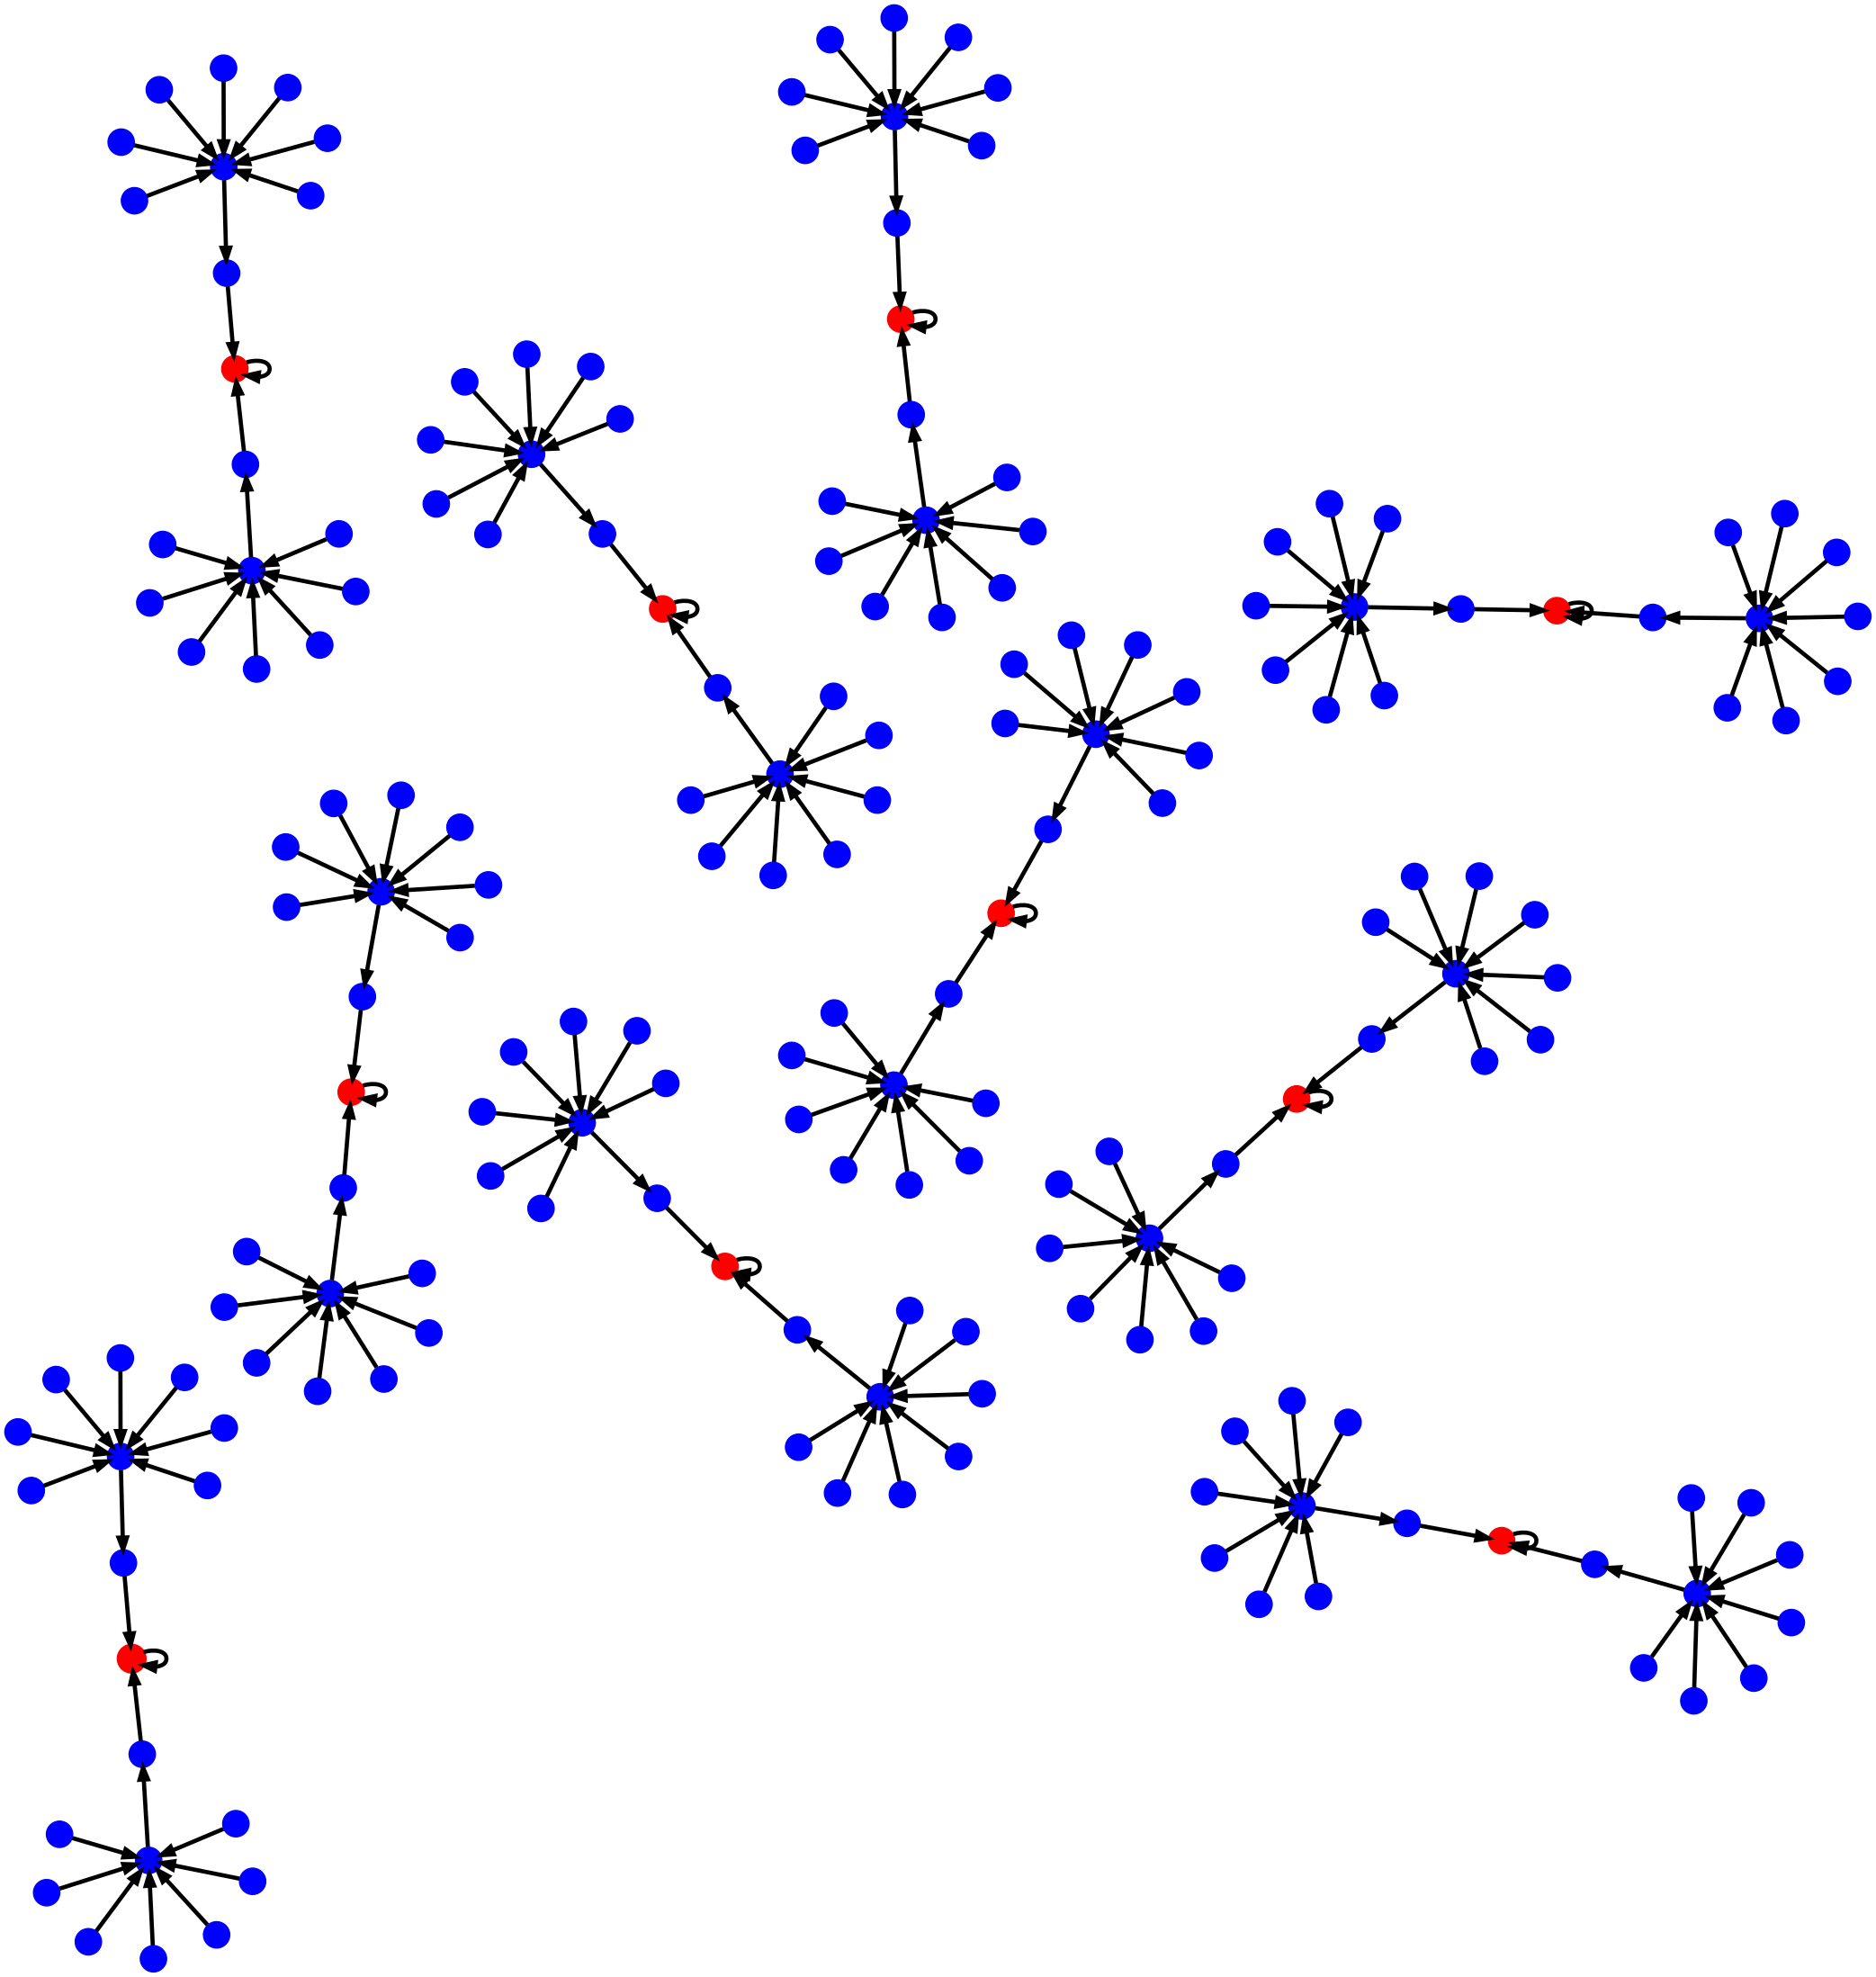

In [14]:
for node in G_nx.nodes():
    is_halting = node in halting_nodes

    G_nx.nodes[node]['label'] = ''
    G_nx.nodes[node]['shape'] = 'circle'
    G_nx.nodes[node]['style'] = 'filled'
    G_nx.nodes[node]['fixedsize'] = 'true'
    G_nx.nodes[node]['width'] = '0.3'
    G_nx.nodes[node]['height'] = '0.3'

    if is_halting:
        G_nx.nodes[node]['fillcolor'] = 'red'
        G_nx.nodes[node]['color'] = 'red'
    else:
        G_nx.nodes[node]['fillcolor'] = 'blue'
        G_nx.nodes[node]['color'] = 'blue'
for u, v in G_nx.edges():
    G_nx[u][v]['penwidth'] = 3.5
    G_nx[u][v]['minlen'] = 4
p = nx.drawing.nx_pydot.to_pydot(G_nx)
p.set_prog('neato')
p.write_pdf('graph.pdf')
p.write_png('graph.png')
G_nx.nodes[node]['penwidth'] = '3'

display(Image(filename='graph.png'))

In [ ]:
## Computing the mismatch cost:

q0 = obtain_q0(G)
q0 = q0[1]


### **1. Choose Parameters**

The binomial distribution has two parameters:

* $n \in \mathbb{N}$: number of trials (controls support size)
* $p \in [0,1]$: probability of success (controls the mean)

Then the binomial distribution is:

$$
P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}, \quad \text{for } k = 0, 1, \dots, n
$$

This gives:

* **Mean**: $\mu = np$
* **Variance**: $\sigma^2 = np(1 - p)$


In [ ]:
from scipy.special import comb

In [ ]:
#Preparing the initial distribution.
def initial_dist(p):
  n = 10
  p_x = np.array([comb(10, k, exact=True)*p**(k)*(1-p)**(n-k) for k in range(n)])
  p_x = p_x / np.sum(p_x)
  p_nin = 1/(1*10*2-1)*np.ones(1*10*2-1)
  p_x0 = np.outer(p_x, p_nin).flatten(order = 'F')
  return p_x0


In [ ]:
p_x0 = initial_dist(0.2)

In [ ]:
q1 = G.T@q0
MMC_list = []
MMC_list2 = []
for p in np.linspace(0.2, 0.8, 3):
  p0 = initial_dist(p)

  #p0 = np.ones(len(unique_hashes)) / len(unique_hashes)
  MMC = []
  MMC2 = []
  mmc = 0
  for t in range(6):
    p1 = G.T@p0
    k = KL(p0, q0)-KL(p1, q1)
    mmc += k
    MMC2.append(mmc)
    MMC.append(k)
    p0 = p1

  MMC_list.append(MMC)
  MMC_list2.append(MMC2)

In [ ]:
plt.style.use('ggplot')

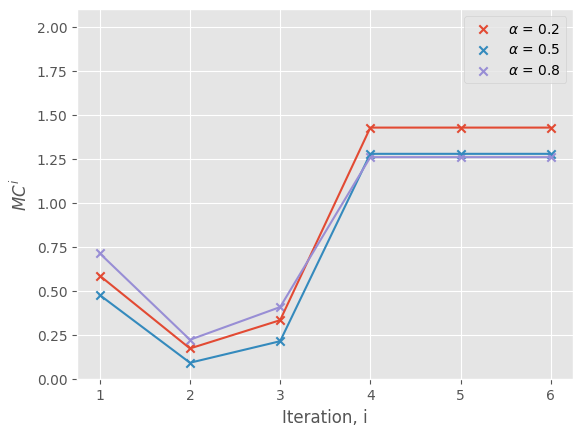

In [ ]:
for i in range(3):
  plt.scatter(range(1, 7), MMC_list[i], marker = 'x', label = r'$\alpha$ = '+str(np.linspace(0.2, 0.8, 3)[i]))
  plt.plot(range(1, 7), MMC_list[i])
# plt.scatter(range(1, 7), MMC)
# plt.plot(range(1, 7), MMC)
plt.ylim(0, 2.1)
plt.ylabel(r'$MC^i$')
plt.xlabel('Iteration, i')
plt.legend()
plt.savefig("heaviside1.pdf", format='pdf', bbox_inches='tight')

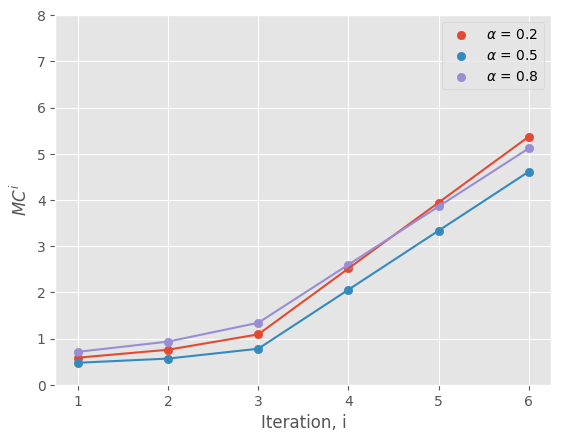

In [ ]:
for i in range(3):
  plt.scatter(range(1, 7), MMC_list2[i], label = r'$\alpha$ = '+str(np.linspace(0.2, 0.8, 3)[i]))
  plt.plot(range(1, 7), MMC_list2[i])
# plt.scatter(range(1, 7), MMC)
# plt.plot(range(1, 7), MMC)
plt.ylim(0, 8)
plt.ylabel(r'$MC^i$')
plt.xlabel('Iteration, i')
plt.legend()
plt.savefig("heaviside2.pdf", format='pdf', bbox_inches='tight')